# Заняття 8 — точний період планети: згортання за фазою

In [3]:
%pip install -r requirements.txt -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Дані з минулого заняття

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("tres2_lightcurve.txt")
t = data[:, 0]
f = data[:, 1]
print(t[:5])
print(f[:5])

[120.53912 120.55955 120.57999 120.60042 120.62086]
[0.999747 0.999342 0.999453 0.999284 0.99939 ]


## Що ми вже знаємо
> Минулого разу побачили провали кожні **~2.47 доби** — це період «на око». Але за 4 роки планета зробила майже **600 обертів**: крихітна похибка в періоді, помножена на 600, усе розмиє. Сьогодні знайдемо **точний** період.

> **Згадай (зроби сам):** намалюй криву потоку лише для проміжку 130–142 доби.

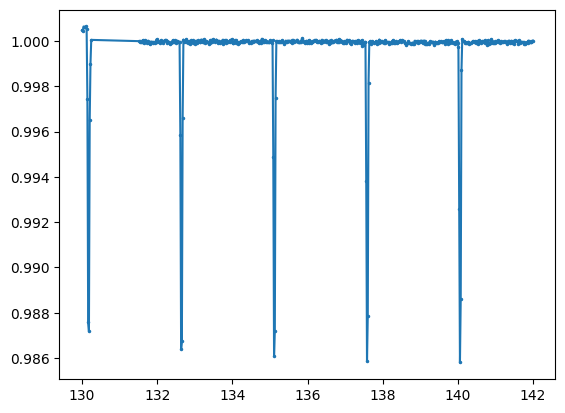

In [17]:
window = (t > 130) & (t < 142)            # тільки проміжок 130-142 доби
plt.plot(t[window], f[window], ".-", markersize=3)

> **Задача 2.** Провали — це планета: проходячи перед зорею, вона затуляє частину світла. Скільки діб минає між двома сусідніми провалами? Це період обертання планети — визнач його з графіка «на око».

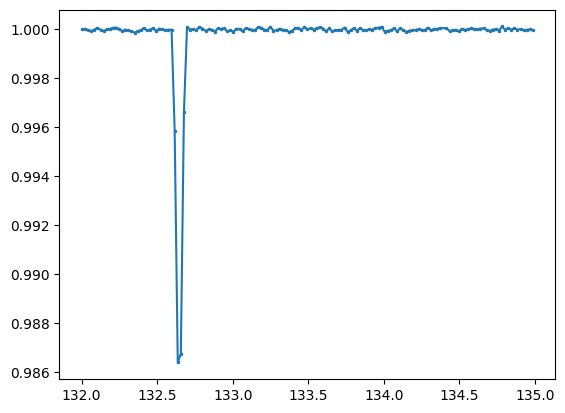

In [5]:
window = (t > 132) & (t < 135)            # тільки проміжок 130-142 доби
plt.plot(t[window], f[window], ".-", markersize=3)

In [21]:
t_window = (t > 132) & (t < 138)
f_window = f < 0.988
#print(t_window[f_window])


## 1. Фаза — де планета в межах одного оберту

> Якщо період `P` відомий, кожен момент часу можна перевести у «фазу» — позицію в межах одного оберту (0..1). Тоді всі 600 обертів накладаються один на одного.

### Крок 1 — будуємо фазу по числах (дивимось, що рахуємо)

In [ ]:
P = 2.47
print(t[:5])             # час, доби
print(t[:5] % P)         # залишок від ділення на P -> де ми в оберті (0..P)
print((t[:5] % P) / P)   # поділили на P -> фаза від 0 до 1

### Крок 2 — згорни сам: намалюй потік від ФАЗИ, а не від часу (P = 2.47)
> Підказка: фаза `= (t % P) / P`, далі звичайний `plt.plot`. Додай `plt.ylim(0.98, 1.005)`, щоб наблизити провал.

## 2. Уточнюємо період руками
> Усі оберти лягли разом, але провал ще **розмазаний** — `P` неточний. Чим точніший період, тим вужчий провал.

### Крок 3 — підбери P сам, щоб провал стиснувся в «голку»
> Міняй останні цифри: 2.470, 2.471, 2.475, 2.4706 … і перезапускай. Відчуй, як різко все залежить від останніх цифр. Який найвужчий провал вдається отримати?

> При P = 2.4706 провал — вузька смужка: майже всі 600 обертів збіглися. Це і є точний період.
> Але підбирати оком — довго й неточно. Хай рахує комп'ютер — тільки йому потрібне **ЧИСЛО**: «наскільки вузький провал».

## 3. Автоматизація: міряємо тісноту провалу «бінами» (смугами)

### Крок 4 — ріжемо фазу 0..1 на смуги. У яку смугу потрапляє точка?
> Беремо 50 смуг. Номер смуги точки = ціла частина від (фаза · 50).

In [ ]:
N = 50
print(0.37 * N)          # точка з фазою 0.37 ...
print(int(0.37 * N))     # ... потрапляє у смугу 18

### Крок 5 — номер смуги для КОЖНОЇ точки одразу

In [ ]:
P = 2.4706
phase = (t % P) / P
bin_index = (phase * N).astype(int)   # .astype(int) — ціла частина для всього масиву
print(phase[:5])
print(bin_index[:5])

### Крок 6 — у кожній смузі усереднюємо потік (через знайому маску!)

In [ ]:
print(f[bin_index == 18].mean())   # середній потік у смузі 18

# те саме для ВСІХ 50 смуг:
curve = np.array([f[bin_index == k].mean() for k in range(N)])
print(curve.round(4))

### Крок 7 — намалюй сам згорнуту криву по смугах
> Центри смуг уже пораховано (`bin_centers`). Намалюй бліді сирі точки (`alpha=0.2`) і поверх — `bin_centers` проти `curve` червоною лінією `"r.-"`. Не забудь `plt.ylim(0.98, 1.005)`.

In [ ]:
bin_centers = (np.arange(N) + 0.5) / N

### Крок 8 — обчисли ЧИСЛО тісноти: глибину найнижчої смуги
> Як глибина провалу в ДЗ: `1 − найменше значення` кривої.

### Крок 9 — пакуємо в функцію fold_depth(P) і порівнюємо правильний vs хибний P

In [ ]:
def fold_depth(P):
    phase = (t % P) / P
    bin_index = (phase * N).astype(int)
    curve = np.array([f[bin_index == k].mean() for k in range(N)])
    return 1 - curve.min()

print(fold_depth(2.4706))   # правильний -> глибокий провал
print(fold_depth(2.50))     # хибний -> майже нічого

### Крок 10 — перебираємо тисячі періодів, беремо найглибший

In [ ]:
Ps = np.arange(2.46, 2.48, 0.0001)             # ~200 пробних періодів
depths = np.array([fold_depth(P) for P in Ps])
plt.plot(Ps, depths)

In [ ]:
best_P = Ps[depths.argmax()]
print(best_P)            # 2.4706

> **Точний період: P ≈ 2.4706 доби** (каталог NASA: 2.470613). Комп'ютер за частку секунди перебрав 200 періодів і знайшов той, на якому 600 обертів складаються найточніше.

> Цей самий метод знаходить планети, **надто тьмяні, щоб побачити оком**: усереднення по смугах витягує провал із шуму. Це наступний рівень.